In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# <font color='blue'>**1. Basic Information**</font>
* Also: handle missing values & duplicates

In [6]:
data = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [8]:
data['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [9]:
data['Sleep Disorder'] = data['Sleep Disorder'].fillna('None') # Handle Missing Values
data = data.drop('Person ID', axis = 1) # Drop Useless Columns
data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [10]:
duplicate_rows = data[data.duplicated()]
print(f"Total duplicate rows: {duplicate_rows.shape[0]}")

Total duplicate rows: 242


In [11]:
df = data.drop_duplicates(keep="first")
print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (132, 12)


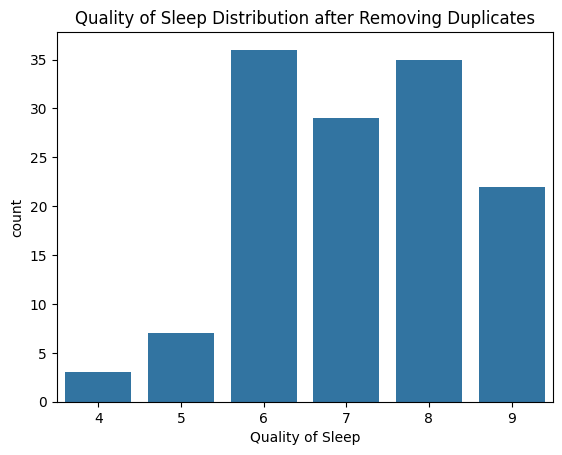

Quality of Sleep
6    0.272727
8    0.265152
7    0.219697
9    0.166667
5    0.053030
4    0.022727
Name: proportion, dtype: float64


In [12]:
sns.countplot(x="Quality of Sleep", data=df)
plt.title("Quality of Sleep Distribution after Removing Duplicates")
plt.show()

print(df["Quality of Sleep"].value_counts(normalize=True))

<font color='purple'>**Remark**: Unfortunately, the dataset becomes small after removing duplicates. However, I believe we can still make the best of it, as we may encounter undesirable datasets in reality. To simplify our task, I have created new categories based on the original `Quality of Sleep`.</font>

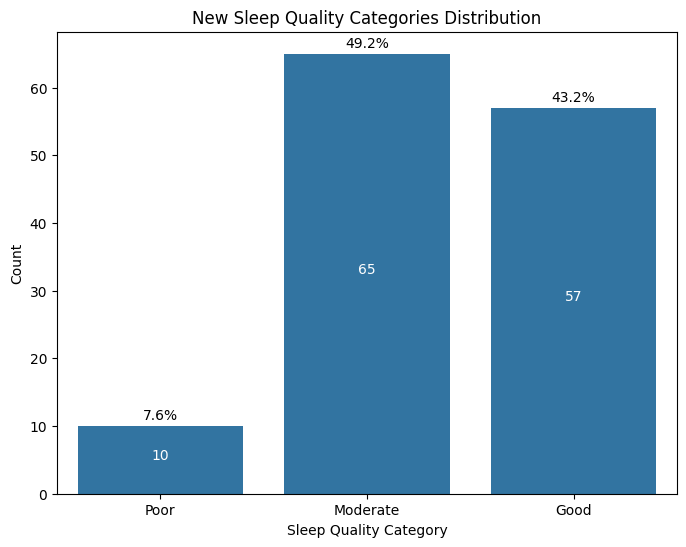

In [13]:
# Define the function to categorize sleep quality
def categorize_sleep(qos):
    if qos >= 8:
        return "Good"
    elif qos <= 5:
        return "Poor"
    else:
        return "Moderate"

# Ensure working with a copy to avoid warnings
df = df.copy()
df["Sleep Quality Category"] = df["Quality of Sleep"].apply(categorize_sleep)

# Calculate counts and proportions for each category
category_counts = df["Sleep Quality Category"].value_counts()
category_proportions = category_counts / len(df)

# Set the order for the x-axis
order = ["Poor", "Moderate", "Good"]

# Create the bar plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x="Sleep Quality Category", data=df, order=order)

# Add percentage labels above each bar
for i, category in enumerate(order):
    count = category_counts[category]
    proportion = category_proportions[category]
    ax.text(i, count + 1, f"{proportion*100:.1f}%", ha="center", fontsize=10, color='black')

# Add total count labels inside each bar
for i, category in enumerate(order):
    count = category_counts[category]
    ax.text(i, count / 2, str(count), ha="center", fontsize=10, color='white')

# Customize the plot title and axis labels
plt.title("New Sleep Quality Categories Distribution")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Count")
plt.show()

In [14]:
print(df["Sleep Quality Category"].value_counts(normalize=True))

Sleep Quality Category
Moderate    0.492424
Good        0.431818
Poor        0.075758
Name: proportion, dtype: float64


In [15]:
df = df.drop('Quality of Sleep', axis = 1) # Drop `Quality of Sleep`

In [16]:
df.describe() # Numerical Variables

,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,41.128788,7.082576,58.393939,5.537879,71.204545,6637.878788
std,8.813942,0.775335,20.468840,1.740428,4.867306,1766.288657
min,27.000000,5.800000,30.000000,3.000000,65.000000,3000.000000
25%,33.750000,6.400000,44.250000,4.000000,68.000000,5000.000000
50%,41.000000,7.150000,60.000000,6.000000,70.000000,7000.000000
75%,49.000000,7.725000,75.000000,7.000000,74.000000,8000.000000
max,59.000000,8.500000,90.000000,8.000000,86.000000,10000.000000


In [17]:
df.describe(include='object') # Classification Variables

,Gender,Occupation,BMI Category,Blood Pressure,Sleep Disorder,Sleep Quality Category
count,132,132,132,132,132,132
unique,2,11,4,25,3,3
top,Male,Nurse,Normal,130/85,None,Moderate
freq,67,29,57,28,73,65


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132 entries, 0 to 366
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   132 non-null    object 
 1   Age                      132 non-null    int64  
 2   Occupation               132 non-null    object 
 3   Sleep Duration           132 non-null    float64
 4   Physical Activity Level  132 non-null    int64  
 5   Stress Level             132 non-null    int64  
 6   BMI Category             132 non-null    object 
 7   Blood Pressure           132 non-null    object 
 8   Heart Rate               132 non-null    int64  
 9   Daily Steps              132 non-null    int64  
 10  Sleep Disorder           132 non-null    object 
 11  Sleep Quality Category   132 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 13.4+ KB


# <font color='blue'>**2. Variables Analysis**</font>

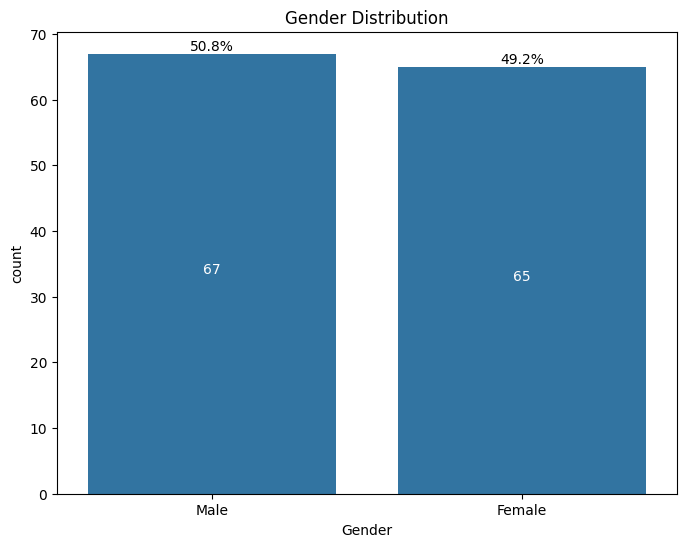

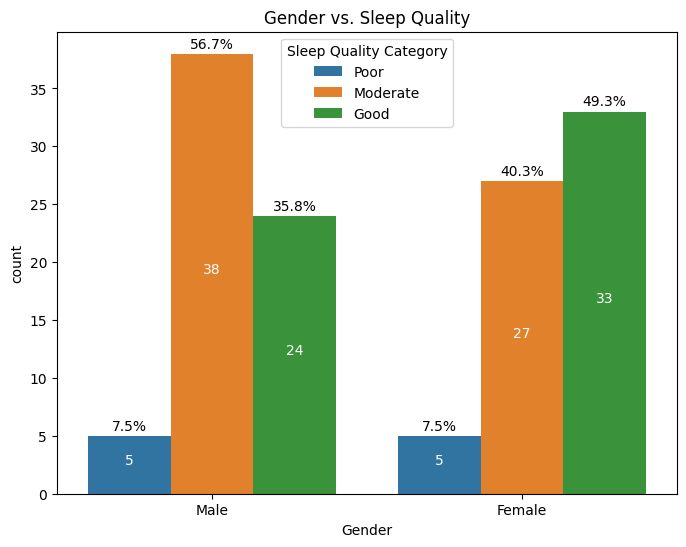

In [19]:
## 1. Gender
# Gender Distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(x="Gender", data=df)

# Add percentage labels above each bar
gender_counts = df['Gender'].value_counts()
gender_proportions = gender_counts / len(df)
for i, gender in enumerate(gender_counts.index):
    count = gender_counts[gender]
    proportion = gender_proportions[gender]
    ax.text(i, count + 0.5, f"{proportion*100:.1f}%", ha="center", fontsize=10, color='black')

# Add total count labels inside each bar
for i, gender in enumerate(gender_counts.index):
    count = gender_counts[gender]
    ax.text(i, count / 2, str(count), ha="center", fontsize=10, color='white')

plt.title("Gender Distribution")
plt.show()

# Gender vs. Sleep Quality
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    x="Gender",
    hue="Sleep Quality Category",
    data=df,
    hue_order=["Poor", "Moderate", "Good"],
)

# Calculate percentages for each bar (by gender)
gender_totals = df.groupby("Gender")["Sleep Quality Category"].count()  # Total counts per gender
for p in ax.patches:
    # Get the height of the bar (count) and calculate percentage
    height = p.get_height()
    if height > 0:  # Avoid division by zero
        gender = p.get_x() + p.get_width() / 2
        proportion = (height / gender_totals.loc[df['Gender'].iloc[int(p.get_x())]]) * 100
        ax.text(p.get_x() + p.get_width() / 2, height + 0.5, f"{proportion:.1f}%", ha="center", fontsize=10, color='black')

# Add total count labels inside each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Avoid displaying zero for empty bars
        ax.text(p.get_x() + p.get_width() / 2, height / 2, str(int(height)), ha="center", fontsize=10, color='white')

plt.title("Gender vs. Sleep Quality")
plt.show()


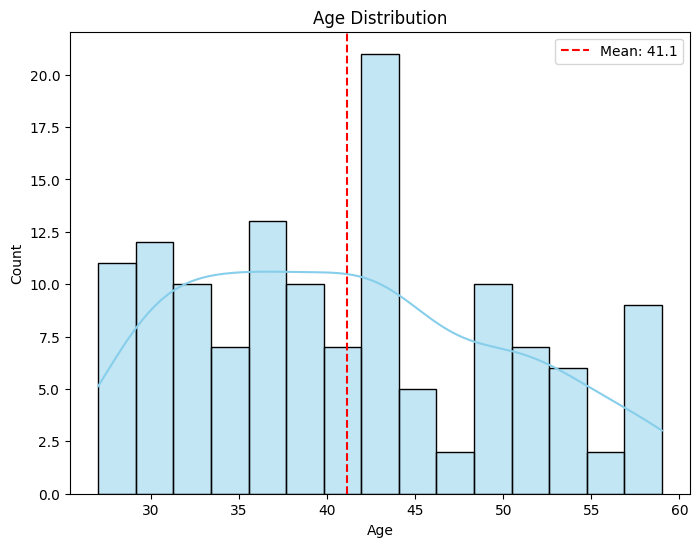

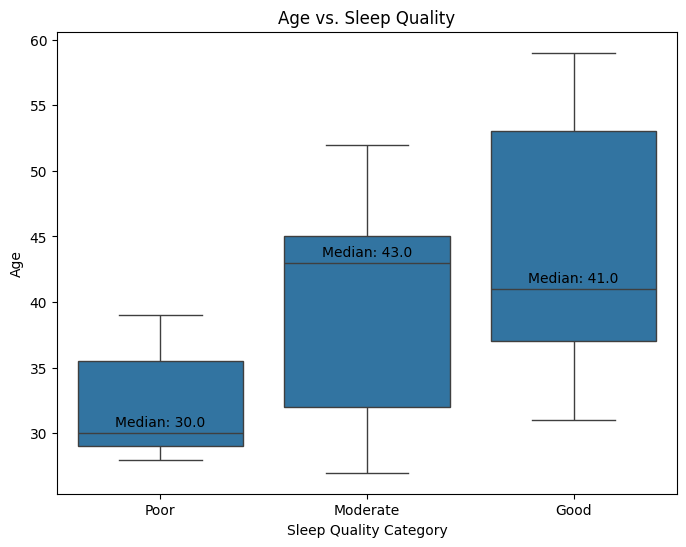

In [20]:
## 2. Age
# Age Distribution Plot
plt.figure(figsize=(8, 6))
ax = sns.histplot(df["Age"], bins=15, kde=True, color="skyblue")

# Add annotation for mean
mean_age = df["Age"].mean()
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean: {mean_age:.1f}')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

# Age vs. Sleep Quality Plot
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Sleep Quality Category", y="Age", data=df, order=["Poor", "Moderate", "Good"])

# Add median annotations above the median line
categories = ["Poor", "Moderate", "Good"]
for i, category in enumerate(categories):
    median = df[df["Sleep Quality Category"] == category]["Age"].median()
    plt.text(i, median + 0.5, f"Median: {median:.1f}", ha="center", color="black", fontsize=10)

plt.title("Age vs. Sleep Quality")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Age")
plt.show()


<font color='purple'>**Remark**: Kernel Density Estimation (KDE) Curve in the first image → Represents the age density.</font>

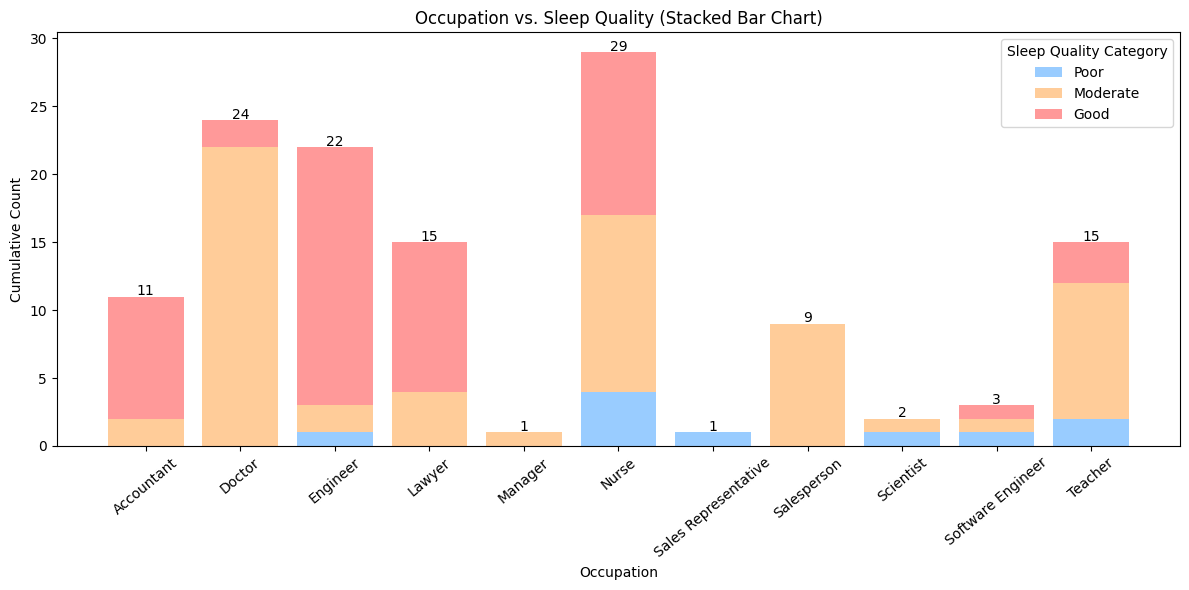

In [21]:
## 3. Occupation
# Group data by occupation and sleep quality category
stacked_data = df.groupby(["Occupation", "Sleep Quality Category"]).size().unstack(fill_value=0)

# Ensure stacking order is Poor -> Moderate -> Good
stacked_data = stacked_data[["Poor", "Moderate", "Good"]]

# Plot stacked bar chart
plt.figure(figsize=(12, 6))
plt.bar(stacked_data.index, stacked_data["Poor"], label="Poor", color="#99CCFF")
plt.bar(stacked_data.index, stacked_data["Moderate"], bottom=stacked_data["Poor"], label="Moderate", color="#FFCC99")
plt.bar(stacked_data.index, stacked_data["Good"], bottom=stacked_data["Poor"] + stacked_data["Moderate"], label="Good", color="#FF9999")

# Add total count labels at the top of each bar
for i, occupation in enumerate(stacked_data.index):
    total = stacked_data.loc[occupation].sum()
    plt.text(i, total + 0.1, str(total), ha="center", fontsize=10, color="black")

# Add labels and title
plt.title("Occupation vs. Sleep Quality (Stacked Bar Chart)")
plt.xlabel("Occupation")
plt.ylabel("Cumulative Count")
plt.xticks(rotation=40)
plt.legend(title="Sleep Quality Category")
plt.tight_layout()
plt.show()


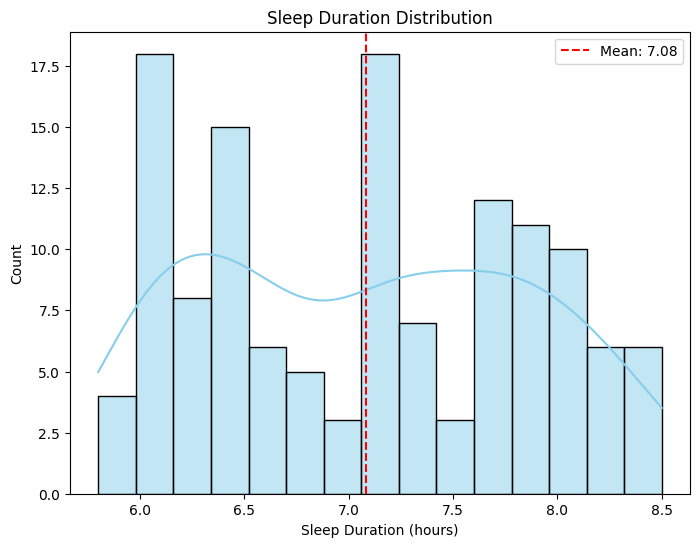

Average Sleep Duration by Sleep Quality:
Sleep Quality Category
Good        7.724561
Moderate    6.638462
Poor        6.310000
Name: Sleep Duration, dtype: float64


In [22]:
## 4. Sleep Duration
# Sleep Duration Distribution Plot
plt.figure(figsize=(8, 6))
ax = sns.histplot(df["Sleep Duration"], bins=15, kde=True, color="skyblue")

# Mean annotation
mean_sleep_duration = df["Sleep Duration"].mean()
plt.axvline(mean_sleep_duration, color='red', linestyle='--', label=f'Mean: {mean_sleep_duration:.2f}')

plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Print Average Sleep Duration by Sleep Quality
sleep_quality_avg = df.groupby("Sleep Quality Category")["Sleep Duration"].mean()
print("Average Sleep Duration by Sleep Quality:")
print(sleep_quality_avg)


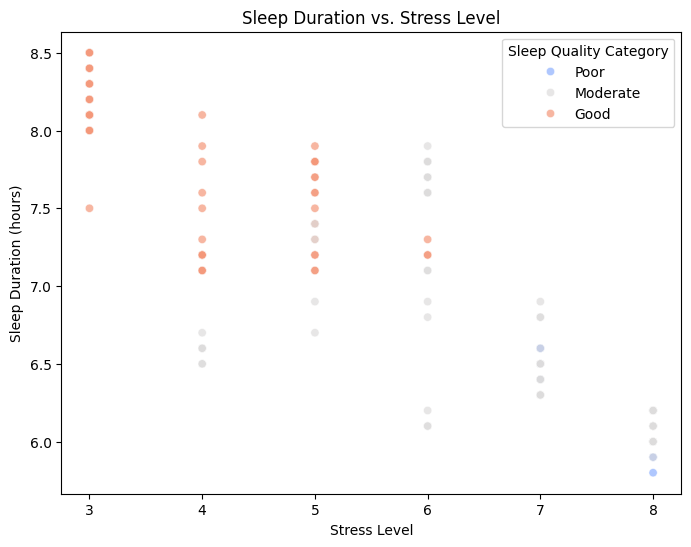

In [23]:
plt.figure(figsize=(8, 6))

# Scatter plot with reordered legend
sns.scatterplot(
    x="Stress Level", 
    y="Sleep Duration", 
    data=df, 
    hue="Sleep Quality Category", 
    hue_order=["Poor", "Moderate", "Good"],  # Manually set order
    palette="coolwarm",
    alpha=0.7  # Adjust transparency to reveal overlapping points
)

# Labels and title
plt.title("Sleep Duration vs. Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Sleep Duration (hours)")

# Adjust legend position and title
plt.legend(title="Sleep Quality Category", loc="upper right")
plt.show()


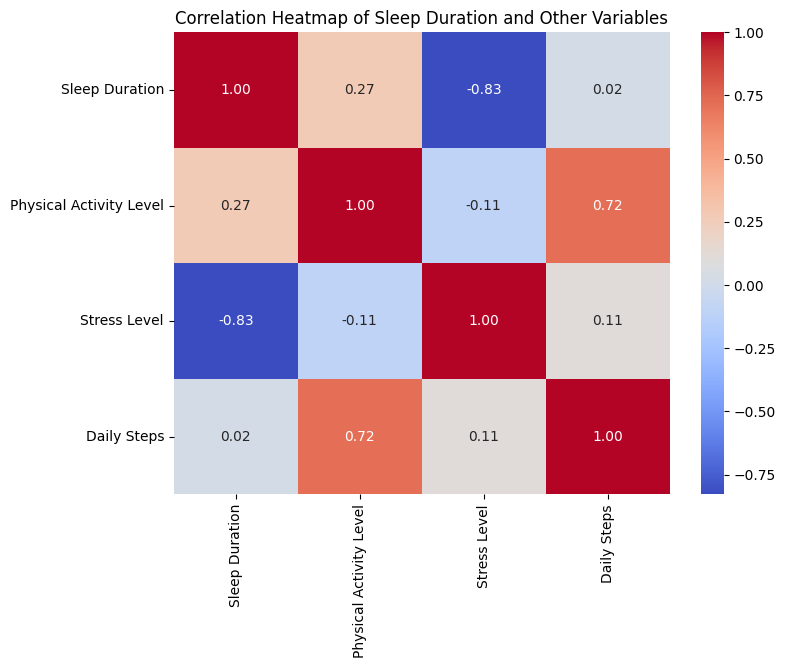

In [24]:
# Correlation heatmap for selected numerical variables
correlation_matrix = df[["Sleep Duration", "Physical Activity Level", "Stress Level", "Daily Steps"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)

# Helps identify relationships between sleep duration and other factors
plt.title("Correlation Heatmap of Sleep Duration and Other Variables")
plt.show()

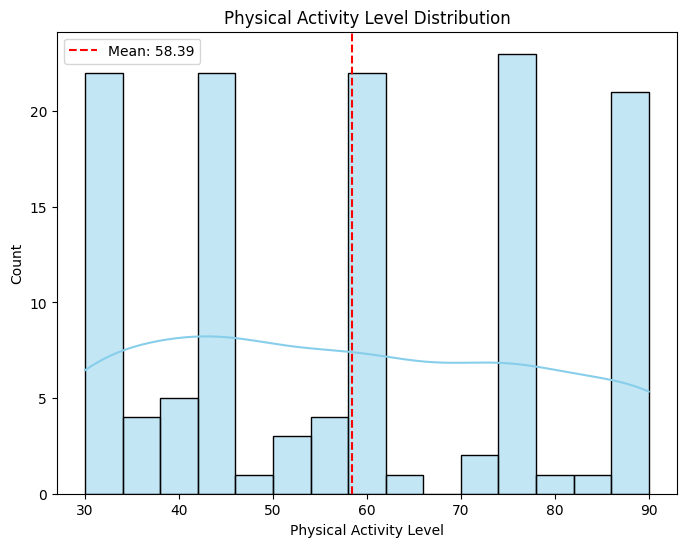

Average Physical Activity Level by Sleep Quality:
Sleep Quality Category
Good        64.298246
Moderate    56.784615
Poor        35.200000
Name: Physical Activity Level, dtype: float64


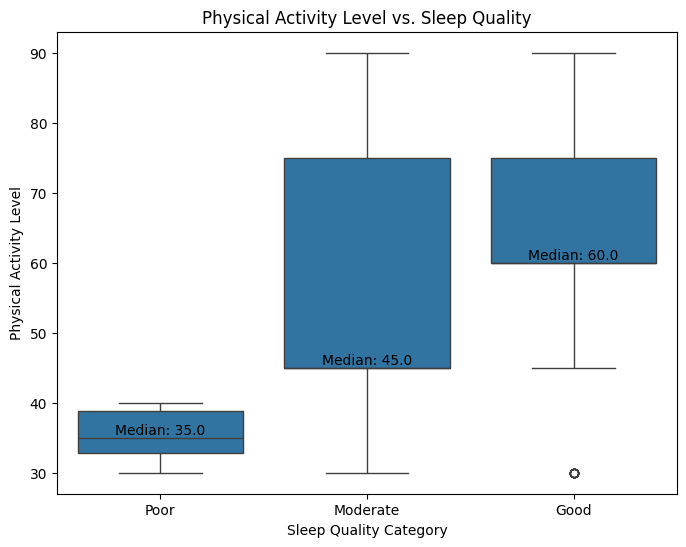

In [25]:
## 5. Physical Activity Level
# Physical Activity Level Distribution Plot
plt.figure(figsize=(8, 6))
ax = sns.histplot(df["Physical Activity Level"], bins=15, kde=True, color="skyblue")

# Add mean line
mean_physical_activity = df["Physical Activity Level"].mean()
plt.axvline(mean_physical_activity, color='red', linestyle='--', label=f'Mean: {mean_physical_activity:.2f}')

plt.title("Physical Activity Level Distribution")
plt.xlabel("Physical Activity Level")
plt.ylabel("Count")
plt.legend()
plt.show()

# Average Physical Activity by Sleep Quality
physical_activity_avg = df.groupby("Sleep Quality Category")["Physical Activity Level"].mean()
print("Average Physical Activity Level by Sleep Quality:")
print(physical_activity_avg)

# Physical Activity vs. Sleep Quality Plot
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x="Sleep Quality Category", y="Physical Activity Level", data=df, order=["Poor", "Moderate", "Good"])

# Add median annotations
for i, category in enumerate(categories):
    median = df[df["Sleep Quality Category"] == category]["Physical Activity Level"].median()
    plt.text(i, median + 0.5, f"Median: {median:.1f}", ha="center", color="black", fontsize=10)

plt.title("Physical Activity Level vs. Sleep Quality")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Physical Activity Level")
plt.show()


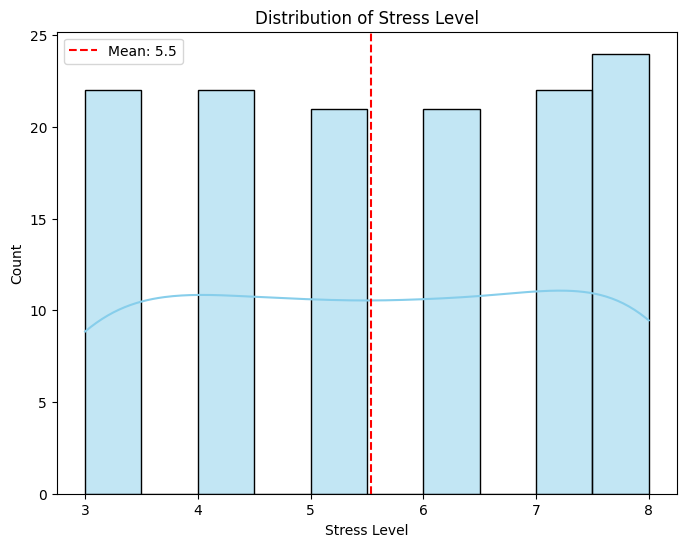

In [26]:
## 6. Stress Level
plt.figure(figsize=(8, 6))
ax = sns.histplot(df["Stress Level"], bins=10, kde=True, color="skyblue")

# Add mean annotation
mean_stress = df["Stress Level"].mean()
plt.axvline(mean_stress, color='red', linestyle='--', label=f'Mean: {mean_stress:.1f}')

plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.legend()
plt.show()


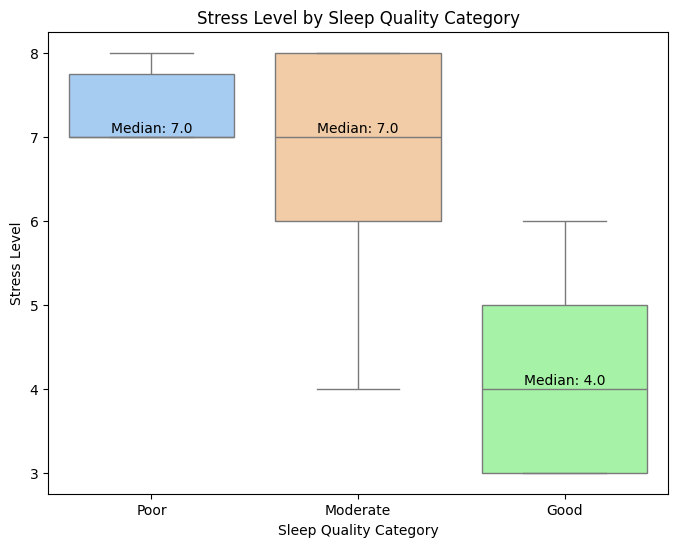

In [27]:
# Boxplot for Stress Level by Sleep Quality Category
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="Sleep Quality Category",
    y="Stress Level",
    data=df,
    order=categories,
    hue="Sleep Quality Category",  # Explicitly assign hue to avoid FutureWarning
    dodge=False,  # Ensure no group offset
    palette={"Poor": "#99CCFF", "Moderate": "#FFCC99", "Good": "#99FF99"}  # Custom colors for each category
)

# Add median annotations above the median line
for i, category in enumerate(categories):
    median = df[df["Sleep Quality Category"] == category]["Stress Level"].median()
    plt.text(i, median + 0.05, f"Median: {median:.1f}", ha="center", color="black", fontsize=10)

# Add title and axis labels
plt.title("Stress Level by Sleep Quality Category")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Stress Level")
plt.show()


In [28]:
## 7. BMI Category
df['BMI Category'].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

<Figure size 800x600 with 0 Axes>

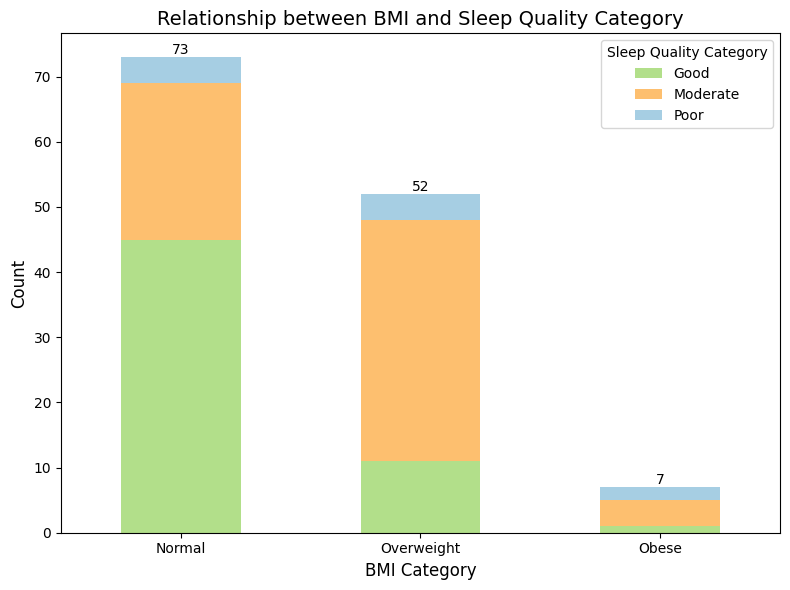

In [29]:
# Merge 'Normal Weight' and 'Normal' into 'Normal'
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})

# Count the number of occurrences for each BMI category
bmi_counts = df["BMI Category"].value_counts()

# Count the occurrences of each combination of BMI and Sleep Quality Category
bmi_sleep_counts = df.groupby(["BMI Category", "Sleep Quality Category"]).size().unstack(fill_value=0)

# Ensure the order is Normal -> Overweight -> Obese
bmi_sleep_counts = bmi_sleep_counts.reindex(["Normal", "Overweight", "Obese"])

# Plot the stacked bar chart
plt.figure(figsize=(8, 6))
colors = {"Poor": "#A6CEE3", "Moderate": "#FDBF6F", "Good": "#B2DF8A"}  # Softer colors
bars = bmi_sleep_counts.plot(kind="bar", stacked=True, color=[colors[col] for col in bmi_sleep_counts.columns], figsize=(8, 6))

# Add total count labels on top of each bar
for i, index in enumerate(bmi_sleep_counts.index):
    total = bmi_sleep_counts.loc[index].sum()
    plt.text(i, total + 0.5, str(total), ha="center", fontsize=10)

# Add title and axis labels
plt.title("Relationship between BMI and Sleep Quality Category", fontsize=14)
plt.xlabel("BMI Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Sleep Quality Category")
plt.tight_layout()
plt.show()

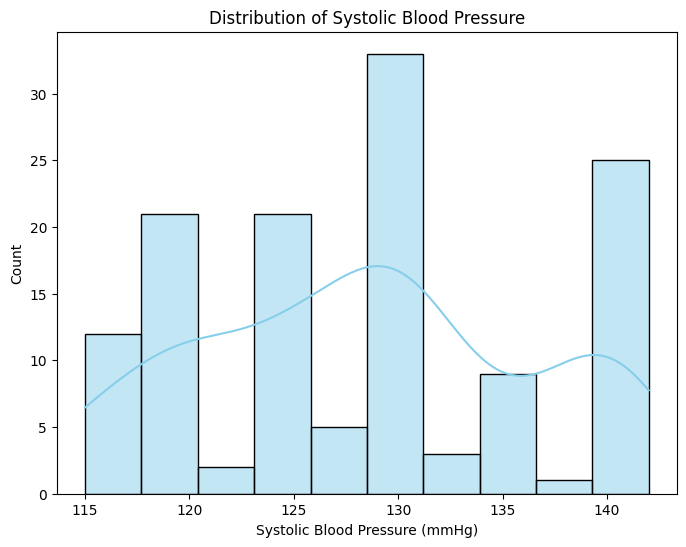

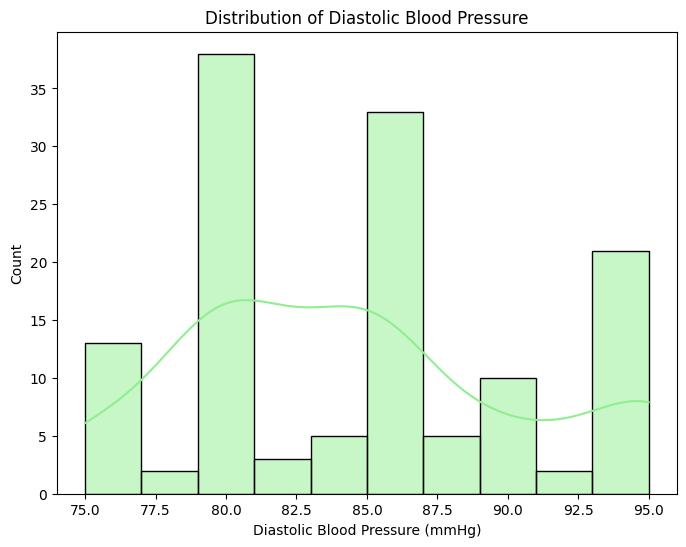

In [30]:
## 8. Blood Pressure
# Split Blood Pressure into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

plt.figure(figsize=(8, 6))
sns.histplot(df['Systolic_BP'], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Systolic Blood Pressure")
plt.xlabel("Systolic Blood Pressure (mmHg)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(df['Diastolic_BP'], bins=10, kde=True, color="lightgreen")
plt.title("Distribution of Diastolic Blood Pressure")
plt.xlabel("Diastolic Blood Pressure (mmHg)")
plt.ylabel("Count")
plt.show()


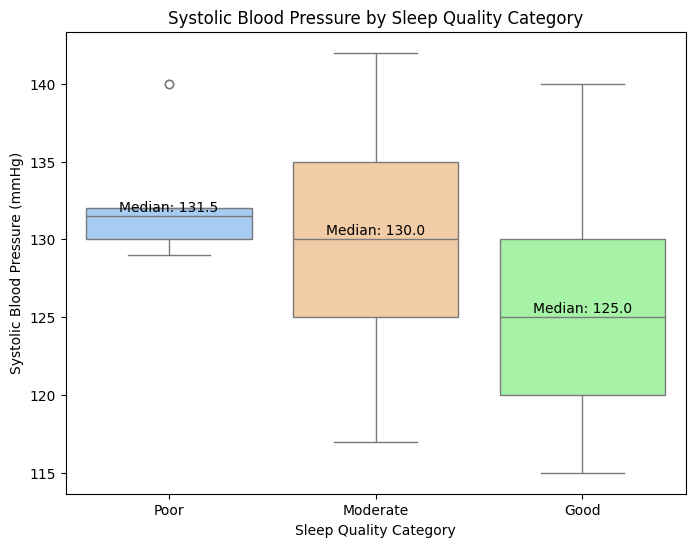

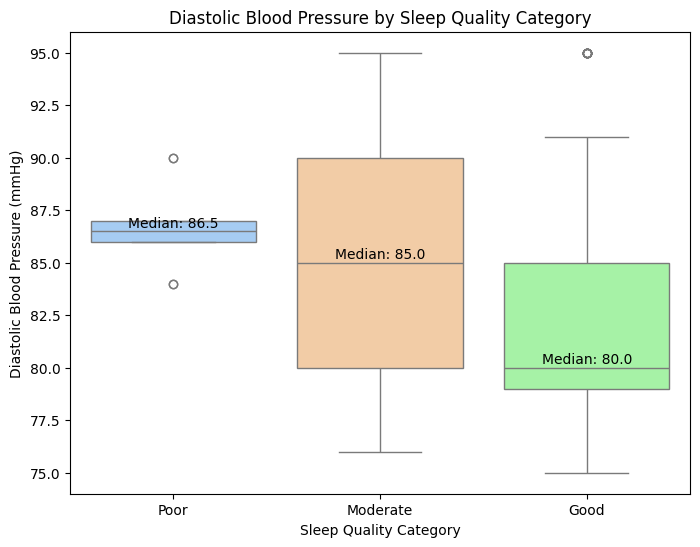

In [31]:
# Boxplot for Systolic Blood Pressure by Sleep Quality Category
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="Sleep Quality Category",
    y="Systolic_BP",
    data=df,
    order=categories,
    hue="Sleep Quality Category",  # Explicitly assign hue to avoid FutureWarning
    dodge=False,  # Ensure no group offset
    palette={"Poor": "#99CCFF", "Moderate": "#FFCC99", "Good": "#99FF99"}  # Custom colors for each category
)

# Add median annotations above the median line
for i, category in enumerate(categories):
    median = df[df["Sleep Quality Category"] == category]["Systolic_BP"].median()
    plt.text(i, median + 0.3, f"Median: {median:.1f}", ha="center", color="black", fontsize=10)

plt.title("Systolic Blood Pressure by Sleep Quality Category")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Systolic Blood Pressure (mmHg)")
plt.show()

# Boxplot for Diastolic Blood Pressure by Sleep Quality Category
plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x="Sleep Quality Category",
    y="Diastolic_BP",
    data=df,
    order=categories,
    hue="Sleep Quality Category",  # Explicitly assign hue to avoid FutureWarning
    dodge=False,
    palette={"Poor": "#99CCFF", "Moderate": "#FFCC99", "Good": "#99FF99"}
)

# Add median annotations above the median line
for i, category in enumerate(categories):
    median = df[df["Sleep Quality Category"] == category]["Diastolic_BP"].median()
    plt.text(i, median + 0.2, f"Median: {median:.1f}", ha="center", color="black", fontsize=10)

plt.title("Diastolic Blood Pressure by Sleep Quality Category")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Diastolic Blood Pressure (mmHg)")
plt.show()


In [32]:
df.head(10)

,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Sleep Quality Category,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,42,6,Overweight,126/83,77,4200,None,Moderate,126,83
1,Male,28,Doctor,6.2,60,8,Normal,125/80,75,10000,None,Moderate,125,80
3,Male,28,Sales Representative,5.9,30,8,Obese,140/90,85,3000,Sleep Apnea,Poor,140,90
5,Male,28,Software Engineer,5.9,30,8,Obese,140/90,85,3000,Insomnia,Poor,140,90
6,Male,29,Teacher,6.3,40,7,Obese,140/90,82,3500,Insomnia,Moderate,140,90
7,Male,29,Doctor,7.8,75,6,Normal,120/80,70,8000,None,Moderate,120,80
10,Male,29,Doctor,6.1,30,8,Normal,120/80,70,8000,None,Moderate,120,80
13,Male,29,Doctor,6.0,30,8,Normal,120/80,70,8000,None,Moderate,120,80
16,Female,29,Nurse,6.5,40,7,Normal,132/87,80,4000,Sleep Apnea,Poor,132,87
17,Male,29,Doctor,6.0,30,8,Normal,120/80,70,8000,Sleep Apnea,Moderate,120,80


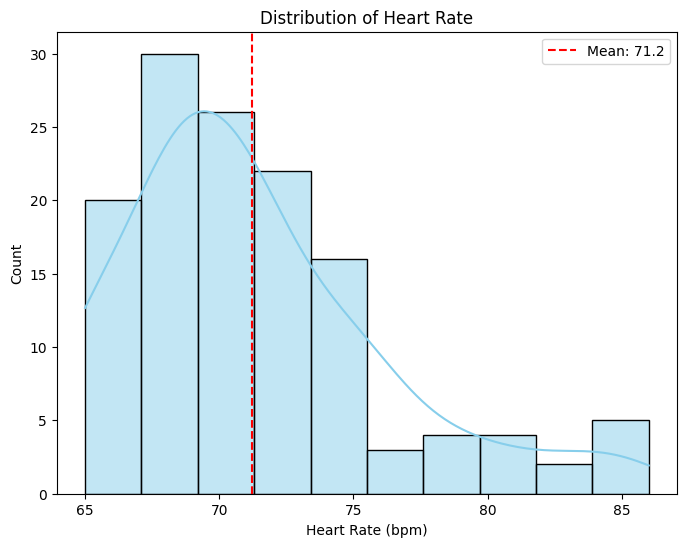

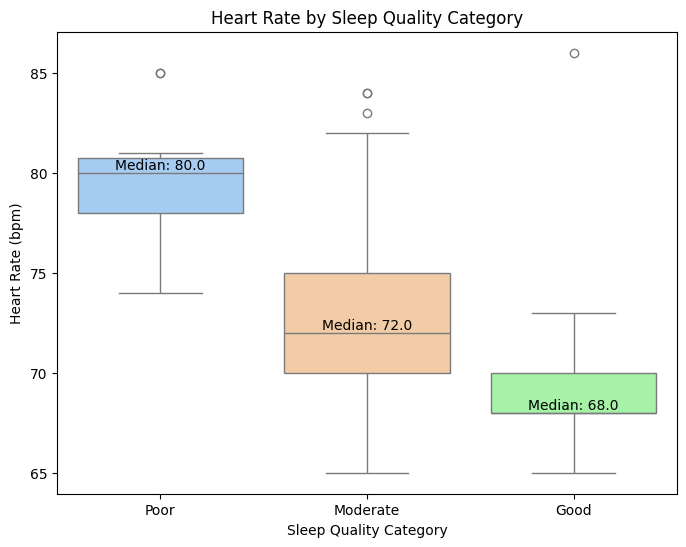

In [33]:
## 9. Heart Rate
plt.figure(figsize=(8, 6))
sns.histplot(df["Heart Rate"], bins=10, kde=True, color="skyblue")
mean_heart_rate = df["Heart Rate"].mean()
plt.axvline(mean_heart_rate, color='red', linestyle='--', label=f'Mean: {mean_heart_rate:.1f}')
plt.title("Distribution of Heart Rate")
plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Count")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(
    x="Sleep Quality Category",
    y="Heart Rate",
    data=df,
    order=categories,
    hue="Sleep Quality Category",  # Explicitly assign hue to avoid FutureWarning
    dodge=False,  # Ensure no group offset
    palette={"Poor": "#99CCFF", "Moderate": "#FFCC99", "Good": "#99FF99"}  # Custom colors for each category
)

# Add median annotations above the median line
for i, category in enumerate(categories):
    median = df[df["Sleep Quality Category"] == category]["Heart Rate"].median()
    plt.text(i, median + 0.15, f"Median: {median:.1f}", ha="center", color="black", fontsize=10)

plt.title("Heart Rate by Sleep Quality Category")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Heart Rate (bpm)")
plt.show()

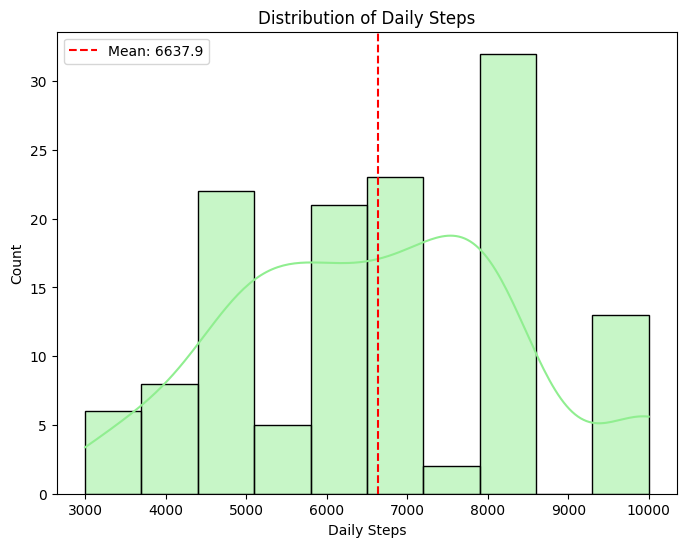

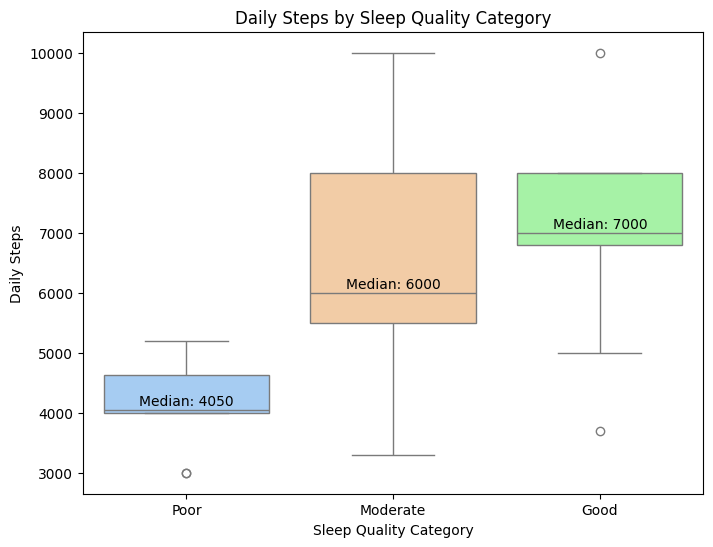

In [34]:
## 10. Daily Steps
plt.figure(figsize=(8, 6))
sns.histplot(df["Daily Steps"], bins=10, kde=True, color="lightgreen")
mean_daily_steps = df["Daily Steps"].mean()
plt.axvline(mean_daily_steps, color='red', linestyle='--', label=f'Mean: {mean_daily_steps:.1f}')
plt.title("Distribution of Daily Steps")
plt.xlabel("Daily Steps")
plt.ylabel("Count")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(
    x="Sleep Quality Category",
    y="Daily Steps",
    data=df,
    order=categories,
    hue="Sleep Quality Category",  # Explicitly assign hue to avoid FutureWarning
    dodge=False,
    palette={"Poor": "#99CCFF", "Moderate": "#FFCC99", "Good": "#99FF99"}  # Custom colors for each category
)

# Add median annotations above the median line
for i, category in enumerate(categories):
    median = df[df["Sleep Quality Category"] == category]["Daily Steps"].median()
    plt.text(i, median + 80, f"Median: {median:.0f}", ha="center", color="black", fontsize=10)

plt.title("Daily Steps by Sleep Quality Category")
plt.xlabel("Sleep Quality Category")
plt.ylabel("Daily Steps")
plt.show()

<Figure size 800x600 with 0 Axes>

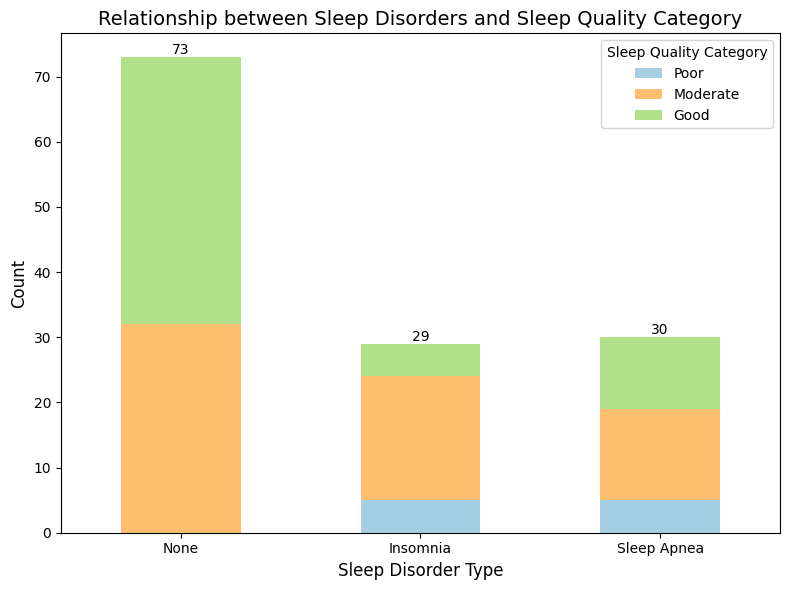

In [35]:
## 11. Sleep Disorder
# Count the occurrences of each combination of Sleep Disorder and Sleep Quality Category
sleep_disorder_quality = df.groupby(["Sleep Disorder", "Sleep Quality Category"]).size().unstack(fill_value=0)

# Ensure the order is None -> Insomnia -> Sleep Apnea
sleep_disorder_quality = sleep_disorder_quality.reindex(["None", "Insomnia", "Sleep Apnea"])

# Ensure the stacking order is Poor -> Moderate -> Good
sleep_disorder_quality = sleep_disorder_quality[["Poor", "Moderate", "Good"]]

# Plot the stacked bar chart
plt.figure(figsize=(8, 6))
colors = {"Poor": "#A6CEE3", "Moderate": "#FDBF6F", "Good": "#B2DF8A"}  # Softer colors
bars = sleep_disorder_quality.plot(kind="bar", stacked=True, color=[colors[col] for col in sleep_disorder_quality.columns], figsize=(8, 6))

# Add total count labels on top of each bar
for i, index in enumerate(sleep_disorder_quality.index):
    total = sleep_disorder_quality.loc[index].sum()
    plt.text(i, total + 0.5, str(total), ha="center", fontsize=10)

# Add title and axis labels
plt.title("Relationship between Sleep Disorders and Sleep Quality Category", fontsize=14)
plt.xlabel("Sleep Disorder Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Sleep Quality Category")
plt.tight_layout()
plt.show()


# <font color='blue'>**3. Encoding & Correlation Analysis**</font>

In [36]:
df.head(10)

,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Sleep Quality Category,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,42,6,Overweight,126/83,77,4200,None,Moderate,126,83
1,Male,28,Doctor,6.2,60,8,Normal,125/80,75,10000,None,Moderate,125,80
3,Male,28,Sales Representative,5.9,30,8,Obese,140/90,85,3000,Sleep Apnea,Poor,140,90
5,Male,28,Software Engineer,5.9,30,8,Obese,140/90,85,3000,Insomnia,Poor,140,90
6,Male,29,Teacher,6.3,40,7,Obese,140/90,82,3500,Insomnia,Moderate,140,90
7,Male,29,Doctor,7.8,75,6,Normal,120/80,70,8000,None,Moderate,120,80
10,Male,29,Doctor,6.1,30,8,Normal,120/80,70,8000,None,Moderate,120,80
13,Male,29,Doctor,6.0,30,8,Normal,120/80,70,8000,None,Moderate,120,80
16,Female,29,Nurse,6.5,40,7,Normal,132/87,80,4000,Sleep Apnea,Poor,132,87
17,Male,29,Doctor,6.0,30,8,Normal,120/80,70,8000,Sleep Apnea,Moderate,120,80


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132 entries, 0 to 366
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   132 non-null    object 
 1   Age                      132 non-null    int64  
 2   Occupation               132 non-null    object 
 3   Sleep Duration           132 non-null    float64
 4   Physical Activity Level  132 non-null    int64  
 5   Stress Level             132 non-null    int64  
 6   BMI Category             132 non-null    object 
 7   Blood Pressure           132 non-null    object 
 8   Heart Rate               132 non-null    int64  
 9   Daily Steps              132 non-null    int64  
 10  Sleep Disorder           132 non-null    object 
 11  Sleep Quality Category   132 non-null    object 
 12  Systolic_BP              132 non-null    int64  
 13  Diastolic_BP             132 non-null    int64  
dtypes: float64(1), int64(7), object

In [38]:
# Select categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Get unique categories for each categorical column
unique_categories = {col: df[col].unique().tolist() for col in categorical_columns}

# Print the unique categories
for col, categories in unique_categories.items():
    print(f"{col}: {categories}")

Gender: ['Male', 'Female']
Occupation: ['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher', 'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer', 'Salesperson', 'Manager']
BMI Category: ['Overweight', 'Normal', 'Obese']
Blood Pressure: ['126/83', '125/80', '140/90', '120/80', '132/87', '130/86', '117/76', '118/76', '128/85', '131/86', '128/84', '115/75', '135/88', '129/84', '130/85', '115/78', '119/77', '121/79', '125/82', '135/90', '122/80', '142/92', '140/95', '139/91', '118/75']
Sleep Disorder: ['None', 'Sleep Apnea', 'Insomnia']
Sleep Quality Category: ['Moderate', 'Poor', 'Good']


In [39]:
df = df.drop('Blood Pressure', axis = 1)

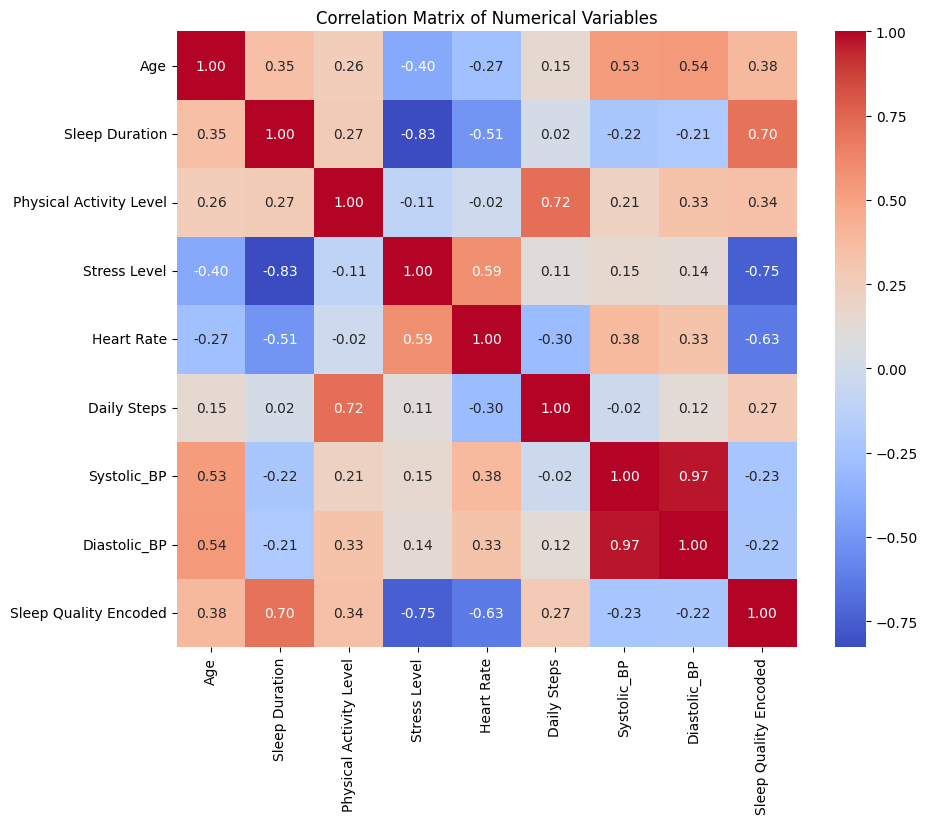

In [40]:
# Define column types
nominal_cols = ['Gender', 'Occupation']  # Nominal variables
ordinal_cols = ['BMI Category', 'Sleep Disorder']  # Ordinal variables
numerical_cols = ['Age', 'Sleep Duration', 'Physical Activity Level', 
                  'Stress Level', 'Heart Rate', 'Daily Steps', 
                  'Systolic_BP', 'Diastolic_BP']  # Numerical variables

# Encode Sleep Quality Category (Target Variable) using map()
sleep_quality_mapping = {"Poor": 0, "Moderate": 1, "Good": 2}
sleep_quality_encoded = df["Sleep Quality Category"].map(sleep_quality_mapping).astype(int)

# Add encoded column to the DataFrame
df["Sleep Quality Encoded"] = sleep_quality_encoded

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols + ["Sleep Quality Encoded"]].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [41]:
# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(sparse_output=False), nominal_cols),  # One-Hot Encoding for nominal variables
        ('ordinal', OrdinalEncoder(), ordinal_cols),  # Ordinal Encoding for ordered variables
        ('scaler', StandardScaler(), numerical_cols)  # Standardize numerical variables
    ])

# Fit and transform data
processed_data = preprocessor.fit_transform(df[nominal_cols + ordinal_cols + numerical_cols])

# Convert processed data back into a DataFrame
processed_df = pd.DataFrame(
    processed_data, 
    columns=preprocessor.get_feature_names_out()
)


<font color='purple'>**Remark**: the dataset is relatively small and suffers from class imbalance, which may require sampling based on the specific machine learning methods you intend to use.</font>

# <font color='blue'>**4. Machine Learning Techniques**</font>

#### **4.1) Random Forest**

Best Parameters for Random Forest:
{'rf__max_depth': None, 'rf__n_estimators': 200, 'smote__k_neighbors': 2}
Best CV Accuracy: 0.945

Random Forest Classification Report on Holdout Test Set:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.95      0.97        20
           2       1.00      1.00      1.00        17

    accuracy                           0.97        40
   macro avg       0.92      0.98      0.94        40
weighted avg       0.98      0.97      0.98        40



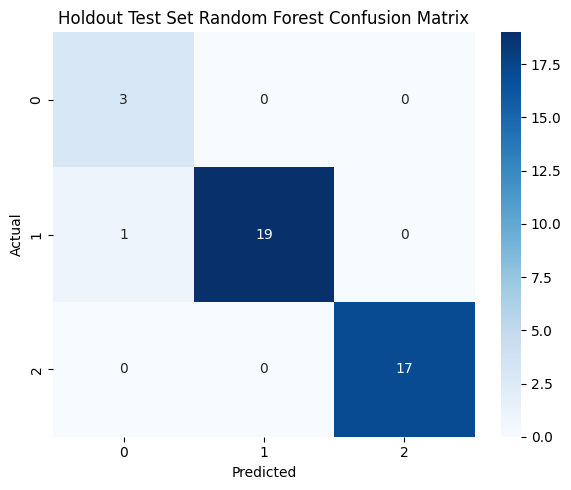

Feature Importances (Descending):
scaler__Stress Level: 0.1643
scaler__Daily Steps: 0.1577
scaler__Heart Rate: 0.1314
scaler__Sleep Duration: 0.1188
scaler__Physical Activity Level: 0.1039
scaler__Age: 0.0843
onehot__Occupation_Doctor: 0.0493
scaler__Systolic_BP: 0.0448
scaler__Diastolic_BP: 0.0434
ordinal__Sleep Disorder: 0.0208
ordinal__BMI Category: 0.0177
onehot__Occupation_Engineer: 0.0171
onehot__Occupation_Teacher: 0.0099
onehot__Occupation_Sales Representative: 0.0084
onehot__Gender_Male: 0.0061
onehot__Gender_Female: 0.0059
onehot__Occupation_Salesperson: 0.0054
onehot__Occupation_Nurse: 0.0037
onehot__Occupation_Lawyer: 0.0027
onehot__Occupation_Accountant: 0.0023
onehot__Occupation_Manager: 0.0012
onehot__Occupation_Software Engineer: 0.0012
onehot__Occupation_Scientist: 0.0000


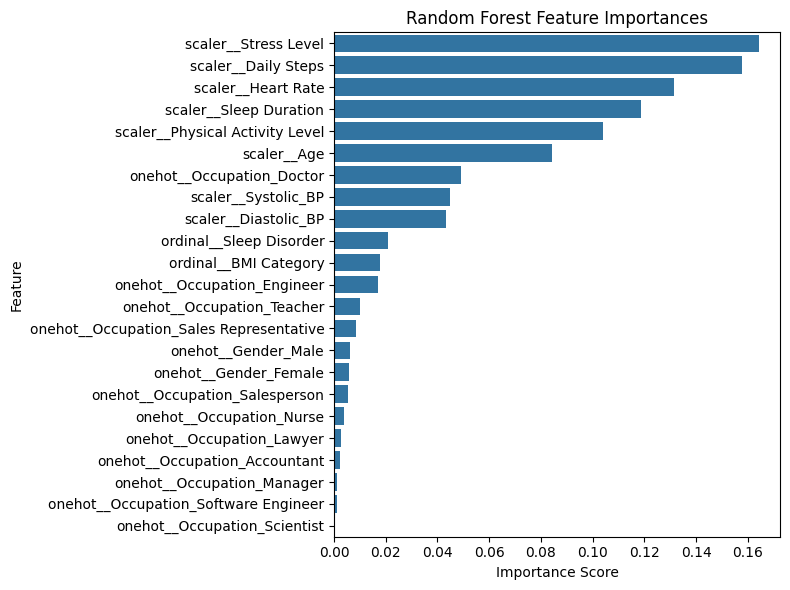

In [42]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = processed_df
y = df["Sleep Quality Encoded"]  # e.g., classes = 0,1,2 or 4,5,6, etc.
labels = sorted(y.unique())

# Split into training (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Define pipeline: SMOTE -> RandomForest
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Parameter grid
param_grid_rf = {
    'smote__k_neighbors': [2, 3],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20]
}

# Stratified K-Fold 
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=param_grid_rf,
    cv=cv_rf,
    scoring='accuracy',
    n_jobs=-1,
    error_score=np.nan
)

grid_rf.fit(X_train, y_train)

print("Best Parameters for Random Forest:")
print(grid_rf.best_params_)
print("Best CV Accuracy: {:.3f}".format(grid_rf.best_score_))

# Evaluate on the holdout test set
y_pred_rf = grid_rf.predict(X_test)
print("\nRandom Forest Classification Report on Holdout Test Set:")
print(classification_report(y_test, y_pred_rf, labels=labels))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Holdout Test Set Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Retrieve the best estimator's Random Forest component
best_rf = grid_rf.best_estimator_.named_steps['rf']

# Extract feature importances and sort them
importances = best_rf.feature_importances_
feature_names = X.columns
sorted_indices = importances.argsort()[::-1]

# Print or plot feature importances
print("Feature Importances (Descending):")
for i in sorted_indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")
plt.figure(figsize=(8, 6))
sns.barplot(x=importances[sorted_indices], y=feature_names[sorted_indices])
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



The holdout test set shows an overall accuracy of 0.97, with nearly perfect precision and recall for classes 1 and 2. Class 0 is slightly underrepresented in the predictions (precision 0.75) but still maintains a high recall (0.86), indicating the model effectively distinguishes the minority class. The confusion matrix confirms that most samples are correctly classified, with only a handful of misclassifications. This suggests the model and SMOTE oversampling together successfully handle class imbalance.

Stress Level, Daily Steps, and Heart Rate stand out as top predictors, indicating that physiological and activity-based factors strongly influence sleep quality in this dataset. Sleep Duration and Physical Activity Level also rank highly, indicating that lifestyle habits correlate with better or worse sleep outcomes. Occupation-related one-hot features show up at the lower end, indicating that profession may have very limited relevance.

Overall, the Random Forest model not only achieves strong predictive performance but also reveals that health and activity factors (stress, steps, heart rate, etc.) dominate in shaping sleep quality predictions.

#### **4.2) Neural Network**


Best Parameters for Neural Network:
{'nn__activation': 'relu', 'nn__hidden_layer_sizes': (128, 64, 32, 16), 'nn__max_iter': 300, 'smote__k_neighbors': 3}
Best CV Accuracy: 0.924

Neural Network Classification Report on Holdout Test Set:
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.94      0.85      0.89        20
           2       0.94      1.00      0.97        17

    accuracy                           0.90        40
   macro avg       0.80      0.84      0.81        40
weighted avg       0.91      0.90      0.90        40



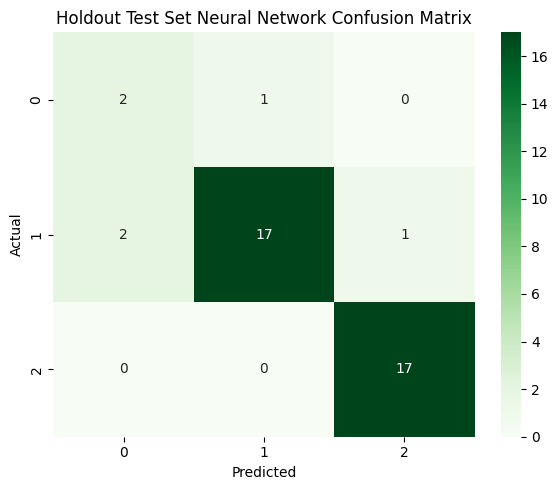

In [43]:
from sklearn.neural_network import MLPClassifier

X = processed_df
y = df["Sleep Quality Encoded"] 
labels = sorted(y.unique()) # or sorted(y.unique()) if you prefer

# Split into training (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Define pipeline: SMOTE -> Neural Network
pipeline_nn = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('nn', MLPClassifier(random_state=42))
])

# Parameter grid
param_grid_nn = {
    'smote__k_neighbors': [2, 3],
    'nn__hidden_layer_sizes': [(128, 64, 32), (128, 64, 32, 16)],
    'nn__activation': ['relu', 'tanh'],
    'nn__max_iter': [300, 500]
}

# Stratified K-Fold 
cv_nn = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nn = GridSearchCV(
    pipeline_nn,
    param_grid=param_grid_nn,
    cv=cv_nn,
    scoring='accuracy',
    n_jobs=-1,
    error_score=np.nan
)

grid_nn.fit(X_train, y_train)

print("\nBest Parameters for Neural Network:")
print(grid_nn.best_params_)
print("Best CV Accuracy: {:.3f}".format(grid_nn.best_score_))

# Evaluate on the holdout test set
y_pred_nn = grid_nn.predict(X_test)
print("\nNeural Network Classification Report on Holdout Test Set:")
print(classification_report(y_test, y_pred_nn, labels=labels))

cm_nn = confusion_matrix(y_test, y_pred_nn, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title("Holdout Test Set Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


The neural network achieves about 90% accuracy on the holdout set, which is noticeably lower than the Random Forest’s 97%. Its confusion matrix shows near-perfect classification for class 2, but moderate performance for class 0. This shortfall compared to Random Forest could be due to the neural network’s sensitivity to hyperparameter tuning and the relatively small representation of minority classes. Nonetheless, it successfully captures non-linear relationships in the data, although it lacks the straightforward feature importance measures.

#### **4.3) Gradient Boosting**

**IMPORTANT NOTE**: Due to the system requirements of using Auto-SKlearn 2.0 (eg. requiring a linux environment to be used), we have opted not to use it as one of our machine learning algorithms. In its place, we decided to use Gradient Boosting via XGBoost. This particular algorithm was chosen because our original intention of choosing Auto-SKlearn was to help provide us with a good baseline, as suggested for its use in class, and XGBoost is used so ubiquetously throughout the industry that we considered it could almost be considered a good 'baseline' of a technique to use in and of itself. Not to mention Gradient Boosting represents one of our most complex non-deep learning models from class, so it can be considered a good gage (along with random forest) for seeing just how good we can expect non-deep learning models to handle this data.

Ultimately, the choice to make the switch here may be better for us in the long run, as based on the implementation that auto-sklearn seems to call for (we still explored the documentation before writing it off entirely), it does indeed leave very little for the Data Scientist to actually do to explore the best possible models. Working instead with XGBoost will at least give us more insight into the positives and negatives of this model in paricular.


Best Parameters for XGBoost:
{'smote__k_neighbors': 2, 'xgb__gamma': 0, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 0, 'xgb__reg_lambda': 0}
Best CV Accuracy: 0.945

XGBoost Classification Report on Holdout Test Set:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.94      0.85      0.89        20
           2       0.89      1.00      0.94        17

    accuracy                           0.90        40
   macro avg       0.84      0.84      0.84        40
weighted avg       0.90      0.90      0.90        40



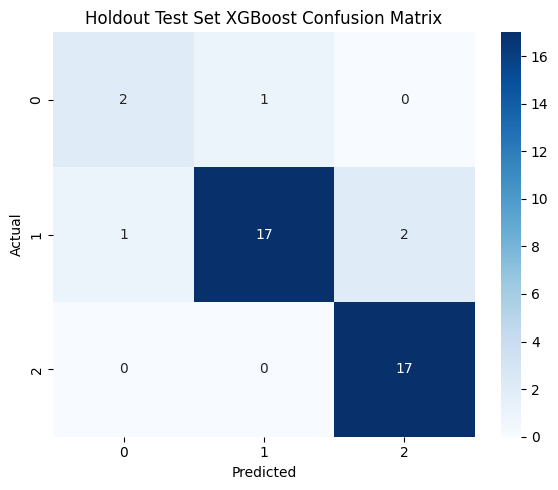

In [44]:
import xgboost as xgb

# Our pipeline: SMOTE -> XGBoost
pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),  # SMOTE for handling class imbalance
    ('xgb', xgb.XGBClassifier(random_state=42))  # XGBoost classifier
])

# Parameter grid for XGBoost (including only
# the most fundamental parameters to reduce complexity).
param_grid_xgb = {
    'smote__k_neighbors': [2, 3],  # SMOTE parameters
    'xgb__max_depth': [3, 6, 9],
    'xgb__learning_rate': [0.01, 0.1, 0.2],  # Learning rate (eta)
    'xgb__n_estimators': [100, 200],  # Number of boosting rounds
    'xgb__gamma': [0, 0.1],  # Minimum loss reduction to make a split
    'xgb__reg_alpha': [0, 0.1],  # L1 regularization in case helpful
    'xgb__reg_lambda': [0, 0.1]  # L2 regularization in case helpful
}

# the rest is as before, just using XGBoost, essentially.
cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=cv_xgb,
    scoring='accuracy',
    n_jobs=-1,
    error_score=np.nan
)
grid_xgb.fit(X_train, y_train)

# Print best parameters and CV accuracy
print("\nBest Parameters for XGBoost:")
print(grid_xgb.best_params_)
print("Best CV Accuracy: {:.3f}".format(grid_xgb.best_score_))

y_pred_xgb = grid_xgb.predict(X_test)
print("\nXGBoost Classification Report on Holdout Test Set:")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
labels = sorted(y_test.unique())  # Get unique class labels

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Holdout Test Set XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

As we see, the Gradient Descent model above achieves an accuracy of 90% on the test set, which is again noticably on par with the previously mentioned Neural Net, and less than that of the Random Forest considerably. It perfectly classified class 2 like the other two models, but fell short slightly with class 1 and class 0 compared to Random Forest, and on par with the neural net for class 0. However, it differed from the neural net in that its class 1 misclassifications favored the more popular class 2 rather than 0. Thus, with the same number of misclassifications, the precision for class 0 was greater. This could be due to a myriad of factors, including those mentioned when discussing the previous models.

As for the feature importances:


Feature Importances (Descending):
scaler__Daily Steps: 0.3433
scaler__Stress Level: 0.2268
scaler__Sleep Duration: 0.1160
onehot__Occupation_Doctor: 0.1052
scaler__Age: 0.0551
scaler__Physical Activity Level: 0.0524
ordinal__BMI Category: 0.0425
scaler__Diastolic_BP: 0.0289
scaler__Heart Rate: 0.0124
onehot__Occupation_Lawyer: 0.0075
ordinal__Sleep Disorder: 0.0060
onehot__Occupation_Teacher: 0.0035
scaler__Systolic_BP: 0.0001
onehot__Occupation_Software Engineer: 0.0001
onehot__Gender_Female: 0.0000
onehot__Occupation_Sales Representative: 0.0000
onehot__Occupation_Engineer: 0.0000
onehot__Occupation_Accountant: 0.0000
onehot__Occupation_Nurse: 0.0000
onehot__Occupation_Manager: 0.0000
onehot__Occupation_Salesperson: 0.0000
onehot__Occupation_Scientist: 0.0000
onehot__Gender_Male: 0.0000


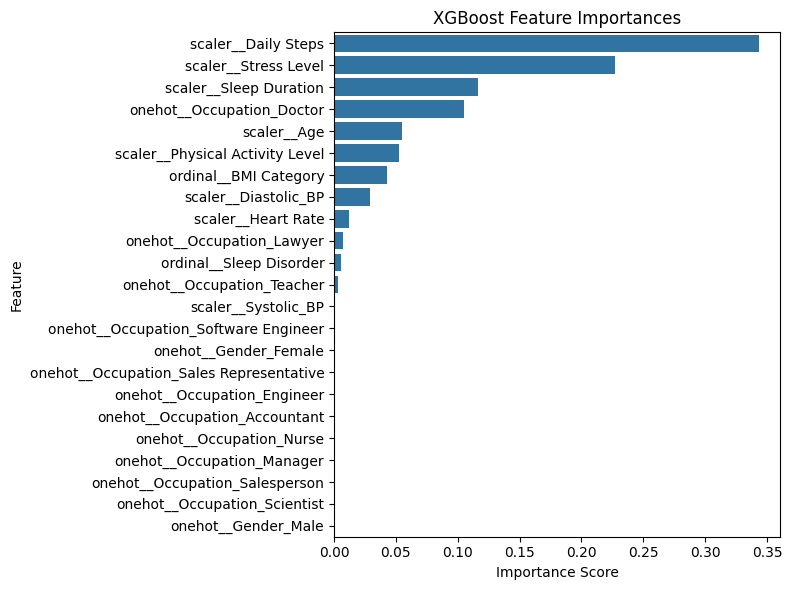

In [45]:
# Like with Random Forest, we can again take 
# a look at the feature importance (done using
# the same methodology as before
best_xgb = grid_xgb.best_estimator_.named_steps['xgb']

importances_xgb = best_xgb.feature_importances_
sorted_indices_xgb = importances_xgb.argsort()[::-1]

# Print feature importances
print("\nFeature Importances (Descending):")
for i in sorted_indices_xgb:
    print(f"{feature_names[i]}: {importances_xgb[i]:.4f}")

# Plot feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x=importances_xgb[sorted_indices_xgb], y=feature_names[sorted_indices_xgb])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Here, we see some interesting differences between the two interpretable models so far. Firstly, while they both maintain daily steps and stress level as the two most important features, they are in the opposite order for XGBoost. Furthermore, where Random Forest had several features with comparably high importance to those two features, XGBoost sets these two features as more than ~twice as important as any of the other features. Thus it seems that XGBoost honed in more on a select few features, whereas Random Forest found use in many - this might suggest that XGBoost would be better suited for a future case where we are given fewer features to work with (either as a nature of the sleep data set iself, or due to computational power us having to narrow down our model to using only the most important features). 

Now, this all being said, there is one aspect of this that we have been failing to address here so far. In viewing these results, it occured to us that so far we are seeing notably lower precision for class 0 compared to the other classes across the board. This, coupled with the imbalanced nature of the dataset itself, suggests to us that perhaps exploring a different performance metric might be advantageous. From our knowledge in class, we decided to choose average precision as this new metric below.


Best Parameters for XGBoost (based on AP):
{'smote__k_neighbors': 2, 'xgb__gamma': 0, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 6, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 0, 'xgb__reg_lambda': 0}
Best CV AP: 0.996

XGBoost Classification Report on Holdout Test Set (AP):
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.95      0.90      0.92        20
           2       0.94      1.00      0.97        17

    accuracy                           0.93        40
   macro avg       0.85      0.86      0.85        40
weighted avg       0.93      0.93      0.92        40



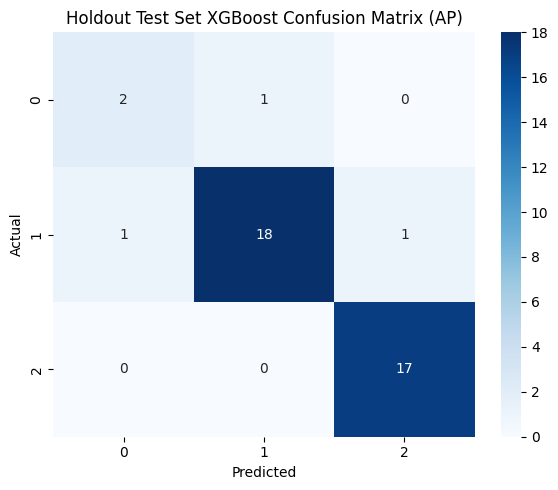

In [46]:
# Same as above, just with the grid search optimizing for 
# Average Precision (AP) instead of accuracy, since the dataset is imbalanced.
ap_pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),  # SMOTE for handling class imbalance
    ('xgb', xgb.XGBClassifier(random_state=42))  # XGBoost classifier
])

ap_grid_xgb = GridSearchCV(
    ap_pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=cv_xgb,
    scoring='average_precision',
    n_jobs=-1,
    error_score=np.nan
)
ap_grid_xgb.fit(X_train, y_train)

print("\nBest Parameters for XGBoost (based on AP):")
print(ap_grid_xgb.best_params_)
print("Best CV AP: {:.3f}".format(ap_grid_xgb.best_score_))

ap_y_pred_xgb = ap_grid_xgb.predict(X_test)
print("\nXGBoost Classification Report on Holdout Test Set (AP):")
print(classification_report(y_test, ap_y_pred_xgb))

ap_cm_xgb = confusion_matrix(y_test, ap_y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(ap_cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Holdout Test Set XGBoost Confusion Matrix (AP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Feature Importances using AP (Descending):
scaler__Daily Steps: 0.2427
scaler__Stress Level: 0.2299
onehot__Occupation_Doctor: 0.1863
scaler__Sleep Duration: 0.0906
scaler__Diastolic_BP: 0.0609
scaler__Age: 0.0511
scaler__Physical Activity Level: 0.0429
onehot__Occupation_Lawyer: 0.0251
scaler__Heart Rate: 0.0221
ordinal__Sleep Disorder: 0.0149
ordinal__BMI Category: 0.0143
onehot__Occupation_Software Engineer: 0.0135
onehot__Occupation_Teacher: 0.0044
scaler__Systolic_BP: 0.0009
onehot__Gender_Female: 0.0001
onehot__Occupation_Engineer: 0.0000
onehot__Occupation_Sales Representative: 0.0000
onehot__Occupation_Accountant: 0.0000
onehot__Occupation_Scientist: 0.0000
onehot__Occupation_Salesperson: 0.0000
onehot__Occupation_Nurse: 0.0000
onehot__Occupation_Manager: 0.0000
onehot__Gender_Male: 0.0000


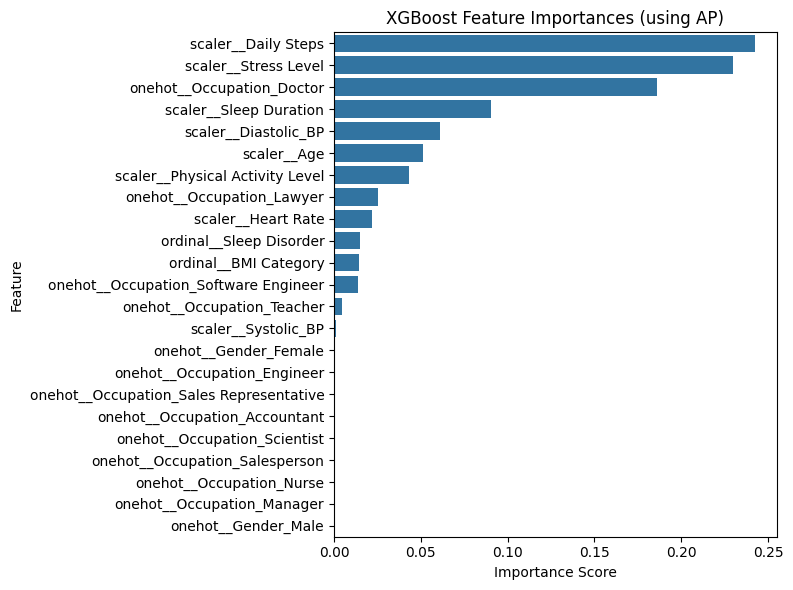

In [47]:
# Same stuff again...
ap_best_xgb = ap_grid_xgb.best_estimator_.named_steps['xgb']

ap_importances_xgb = ap_best_xgb.feature_importances_
ap_sorted_indices_xgb = ap_importances_xgb.argsort()[::-1]

# Print feature importances
print("\nFeature Importances using AP (Descending):")
for i in ap_sorted_indices_xgb:
    print(f"{feature_names[i]}: {ap_importances_xgb[i]:.4f}")

# Plot feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x=ap_importances_xgb[ap_sorted_indices_xgb], y=feature_names[ap_sorted_indices_xgb])
plt.title("XGBoost Feature Importances (using AP)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Interestingly enough, in using the AP as our performance metric, we see our accuracy on the test set increase from 90% to 93%, fewer misclassifications compared to before, using the same model type. Other standard interesting notes on this model include that it used a faster learning rate, with a greater max depth, and maintained a lack in regularization like before.

Additionally, regarding the feature importances, we see that daily steps & stress level remain the most important; however, we also see that when evaluating based on AP, a third feature of being a Doctor as ones' occupation emerges as a notably important feature.

#### **4.4) Support Vector Machines (OVR)**


Best Parameters for SVM:
{'smote__k_neighbors': 2, 'svm__estimator__C': 10, 'svm__estimator__gamma': 'scale', 'svm__estimator__kernel': 'linear'}
Best CV Accuracy: 0.935

SVM Classification Report on Holdout Test Set:
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.90      0.90      0.90        20
           2       1.00      0.94      0.97        17

    accuracy                           0.90        40
   macro avg       0.80      0.84      0.81        40
weighted avg       0.91      0.90      0.90        40



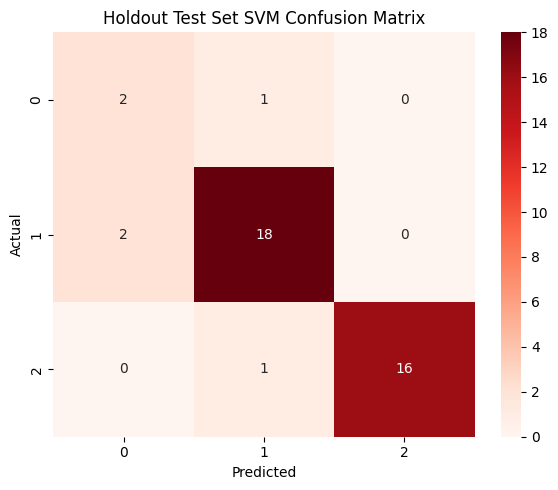

In [48]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

# Our pipeline once again: SMOTE -> SVM (One-vs-Rest)
pipeline_svm = Pipeline([
    ('smote', SMOTE(random_state=42)),  # SMOTE for handling class imbalance
    ('svm', OneVsRestClassifier(SVC(random_state=42)))  # SVM with One-vs-Rest
])

# Parameter grid for SVM, which we can explore
# a bit more since there are fewer major 
# hyperparameters for SVM compared to the others
param_grid_svm = {
    'smote__k_neighbors': [2, 3],  # SMOTE parameters
    'svm__estimator__C': [0.1, 0.5, 1, 10],  # Regularization parameter
    'svm__estimator__kernel': ['linear', 'rbf'],  # Kernel type
    'svm__estimator__gamma': ['scale', 'auto']  # Kernel coefficient for 'rbf'
}

# Stratified K-Fold Cross-Validation
cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV for hyperparameter tuning based on accuracy first
grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid=param_grid_svm,
    cv=cv_svm,
    scoring='accuracy',
    n_jobs=-1,
    error_score=np.nan
)
# Again, the same old stuff as before, just with the SVM now:

grid_svm.fit(X_train, y_train)

print("\nBest Parameters for SVM:")
print(grid_svm.best_params_)
print("Best CV Accuracy: {:.3f}".format(grid_svm.best_score_))

y_pred_svm = grid_svm.predict(X_test)
print("\nSVM Classification Report on Holdout Test Set:")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels, yticklabels=labels)
plt.title("Holdout Test Set SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Interestingly enough, here we see that the SVM performed on par with the latter 2 models we've seen so far, with an accuracy at 90% on the test set. This is surprising considering the fact that SVMs are generally considered to be less complex from a theoretical perspective, and to be less intensive to train and use (unless you are classifying with a one-versus-one approach, maybe) - and yet it performed on par with the Neural Net and the XGBoost Gradient Boosting model. Perhaps this is due to the small size of the data set, leading to the margin of error for the accuracy of the models to sync up more-or less. This is potentially further supported by the fact that the misclassifications made by the SVM are markedly different from those of the prior two models, with one misclassification of a class 2 point into class 1, and no misclassification of any points from 1 into class 2.  

Note: since we have a linear kernel as our best model, we can in fact take a look at the feature importances. Here, the importances are a little different, since we are technically training 3 different models in the OVR technique. Here are the feature importances seperately:

In [49]:
# First we need the best OneVsRestClassifier model
best_ovr = grid_svm.best_estimator_.named_steps['svm']

# And then we extract the underlying SVM estimators for each class
svm_estimators = best_ovr.estimators_

# These we can print directly for each class, after a little 
# bit of reformatting and sorting and such.
print("\nFeature Importances (Descending in Magnitude):")
for class_idx, svm_estimator in enumerate(svm_estimators):
    importances = svm_estimator.coef_.flatten()  # Flatten coefficients for the class
    sorted_indices = np.argsort(np.abs(importances))[::-1]  # Sort by absolute value

    print(f"\nClass {class_idx} Feature Importances:")
    for i in sorted_indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")

# Note: I feel it is better to not plot them this time, since 
# There is already so much clutter without plotting them, 


Feature Importances (Descending in Magnitude):

Class 0 Feature Importances:
scaler__Physical Activity Level: -1.3438
onehot__Occupation_Teacher: 1.1087
onehot__Occupation_Software Engineer: -1.0870
scaler__Daily Steps: -0.9810
onehot__Occupation_Nurse: 0.9119
scaler__Age: -0.8483
scaler__Stress Level: 0.8297
onehot__Occupation_Doctor: -0.8069
scaler__Diastolic_BP: 0.7804
scaler__Systolic_BP: 0.6638
onehot__Gender_Female: -0.5162
onehot__Gender_Male: 0.5162
onehot__Occupation_Lawyer: -0.3954
scaler__Heart Rate: 0.2747
onehot__Occupation_Engineer: 0.2687
scaler__Sleep Duration: -0.2261
ordinal__BMI Category: 0.1854
ordinal__Sleep Disorder: -0.0002
onehot__Occupation_Scientist: 0.0000
onehot__Occupation_Salesperson: 0.0000
onehot__Occupation_Sales Representative: 0.0000
onehot__Occupation_Manager: 0.0000
onehot__Occupation_Accountant: 0.0000

Class 1 Feature Importances:
onehot__Occupation_Doctor: 3.8794
onehot__Occupation_Nurse: -2.1872
onehot__Occupation_Accountant: -1.8794
onehot__Oc

We see here that the values are a little hard to interpret since they are divided by class, but the most important predictor for each class (when selected as the "one" in the "One-VS-Rest" classification) are the ones near the top of the list, having the highest magnitude (representing their coefficients). So, for Class 0, we see physical activity level is most important, where as for Class 1 and Class 2, being or not being a doctor is the most important, with it holding a much higher importance (in the opposite direction, too) in Class 1 compared to Class 2.

To analyze the model as a whole, we should still try to take a look at an aggregated form of the importances in some form. So, I just took their l1 average and plotted that. Note, I decided to use an unweighted average because I feel it would better include the importance from Class 0 into the mix, rather than essentially casting it to the side seeing as it only has 3 points in the test set.


Aggregated Feature Importances (Descending):
onehot__Occupation_Doctor: 2.1105
scaler__Stress Level: 1.1776
onehot__Occupation_Accountant: 1.1003
onehot__Occupation_Nurse: 1.0330
onehot__Occupation_Teacher: 0.9971
scaler__Physical Activity Level: 0.9405
onehot__Occupation_Software Engineer: 0.8737
scaler__Age: 0.7395
onehot__Occupation_Lawyer: 0.7316
scaler__Systolic_BP: 0.7165
ordinal__BMI Category: 0.7056
scaler__Daily Steps: 0.6429
onehot__Gender_Male: 0.6197
onehot__Gender_Female: 0.6197
onehot__Occupation_Engineer: 0.6019
scaler__Heart Rate: 0.5131
scaler__Diastolic_BP: 0.4778
scaler__Sleep Duration: 0.4676
ordinal__Sleep Disorder: 0.0650
onehot__Occupation_Sales Representative: 0.0000
onehot__Occupation_Salesperson: 0.0000
onehot__Occupation_Manager: 0.0000
onehot__Occupation_Scientist: 0.0000


/var/folders/9y/h1y05jt94292c2r0z58gmvxc0000gn/T/ipykernel_20147/2274194728.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aggregated_importances[sorted_indices], y=feature_names[sorted_indices], palette='viridis')


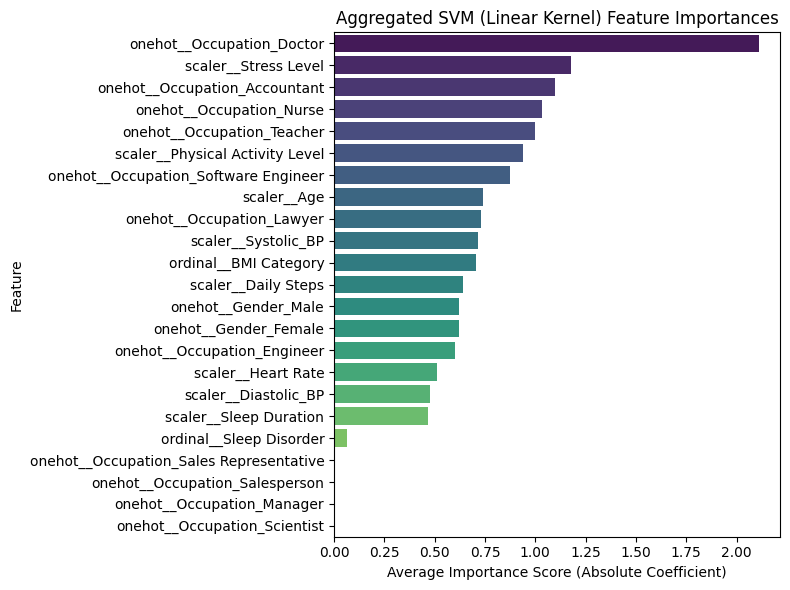

In [50]:
# First, we initialize our array to store the aggregate importances:
aggregated_importances = np.zeros(X.shape[1]) 

# Then we aggregate the coefficients/importances themselves via
# an l1 norm, and average over this:
for svm_estimator in svm_estimators:
    aggregated_importances += np.abs(svm_estimator.coef_.flatten())  # Sum absolute coefficients
aggregated_importances /= len(svm_estimators)  # Divide by number of classes

# Then we do our sorting and printing and all that like before
sorted_indices = np.argsort(aggregated_importances)[::-1]
feature_names = X.columns  # Assuming X is your original feature DataFrame
print("\nAggregated Feature Importances (Descending):")
for i in sorted_indices:
    print(f"{feature_names[i]}: {aggregated_importances[i]:.4f}")

# Since there is only one list of importances now,
# I am happy to plot them too.
plt.figure(figsize=(8, 6))
sns.barplot(x=aggregated_importances[sorted_indices], y=feature_names[sorted_indices], palette='viridis')
plt.title("Aggregated SVM (Linear Kernel) Feature Importances")
plt.xlabel("Average Importance Score (Absolute Coefficient)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

As we might expect from before, Occupation being "Doctor" is the most important feature for this model in general, with stress level being the next most important, but at quite the distance. Interestingly, while this was seen as a fairly impactful feature in the other models before, it was never considered the top, let alone such a dominatingly impactful one.

For the sake of consistency, we can also take a look at this model using Average Precision (AP) as the performance metric:


Best Parameters for SVM (AP):
{'smote__k_neighbors': 3, 'svm__estimator__C': 10, 'svm__estimator__gamma': 'scale', 'svm__estimator__kernel': 'rbf'}
Best CV AP: 0.944

SVM Classification Report on Holdout Test Set (AP):
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.95      0.90      0.92        20
           2       1.00      1.00      1.00        17

    accuracy                           0.93        40
   macro avg       0.82      0.86      0.83        40
weighted avg       0.94      0.93      0.93        40



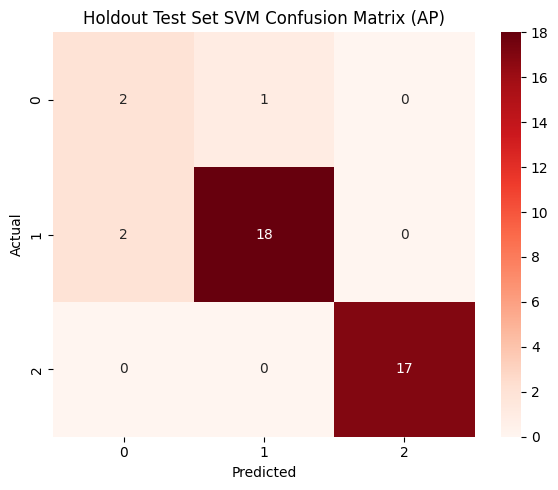

In [51]:
# Our pipeline once again: SMOTE -> SVM (One-vs-Rest)
ap_pipeline_svm = Pipeline([
    ('smote', SMOTE(random_state=42)),  # SMOTE for handling class imbalance
    ('svm', OneVsRestClassifier(SVC(random_state=42)))  # SVM with One-vs-Rest
])

# Stratified K-Fold Cross-Validation
ap_cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV for hyperparameter tuning based on accuracy first
ap_grid_svm = GridSearchCV(
    ap_pipeline_svm,
    param_grid=param_grid_svm,
    cv=ap_cv_svm,
    scoring='average_precision',
    n_jobs=-1,
    error_score=np.nan
)
# Again, the same old stuff as before, just using AP:
ap_grid_svm.fit(X_train, y_train)

print("\nBest Parameters for SVM (AP):")
print(ap_grid_svm.best_params_)
print("Best CV AP: {:.3f}".format(ap_grid_svm.best_score_))

ap_y_pred_svm = ap_grid_svm.predict(X_test)
print("\nSVM Classification Report on Holdout Test Set (AP):")
print(classification_report(y_test, ap_y_pred_svm))

ap_cm_svm = confusion_matrix(y_test, ap_y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(ap_cm_svm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels, yticklabels=labels)
plt.title("Holdout Test Set SVM Confusion Matrix (AP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Like before with the gradient boosted model, we see that the the accuracy on the test set improved again by using average precision as the performance metric, from 90% to 93%, with one less misclassification. This, along with our other findings from the other models (where possible), seems to suggest that using average precision might be a better approach to training models on this dataset, considering just how imbalanced it is.

Sadly, since we are using rbf as our Kernel, we can't actually take a look at the feature importances. However, based on the rest of our analysis, we do have somewhat of a good idea of which features are most impactful to predicting the classes compared to others.